In [2]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 매니저에 직접 파일 등록 (캐시 에러를 우회하는 가장 확실한 방법)
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf')

# 폰트 및 마이너스 깨짐 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

FileNotFoundError: [Errno 2] No such file or directory: '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

In [4]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/AI실무기본_1주차/02_데이터분석프로젝트/team_project/dataset/서울시 지하철 호선별 역별 시간대별 승하차 인원 정보.csv", encoding='euc-kr')

In [7]:
df

,사용월,호선명,지하철역,04시-05시 승차인원,04시-05시 하차인원,05시-06시 승차인원,05시-06시 하차인원,06시-07시 승차인원,06시-07시 하차인원,07시-08시 승차인원,...,23시-24시 하차인원,00시-01시 승차인원,00시-01시 하차인원,01시-02시 승차인원,01시-02시 하차인원,02시-03시 승차인원,02시-03시 하차인원,03시-04시 승차인원,03시-04시 하차인원,작업일자
0,202106,1호선,동대문,715,14,13235,2131,8936,6979,14776,...,8211,16,1434,1,1,0,0,0,0,20210703
1,202106,1호선,동묘앞,51,1,3218,1100,3422,4802,5896,...,2589,4,1348,0,0,0,0,0,0,20210703
2,202106,1호선,서울역,654,17,9008,6400,12474,37203,37253,...,8024,30,637,0,1,0,0,0,0,20210703
3,202106,1호선,시청,37,0,1881,4340,2948,21443,6280,...,1485,3,92,0,0,0,0,0,0,20210703
4,202106,1호선,신설동,343,3,8150,3192,8131,10929,17021,...,5451,10,449,0,0,0,0,0,0,20210703
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45333,201501,중앙선,운길산,0,0,177,56,642,403,1292,...,633,3,222,0,0,0,0,0,0,20151223
45334,201501,중앙선,원덕,1,0,292,4,415,46,537,...,383,3,157,0,0,0,0,0,0,20151223
45335,201501,중앙선,중랑,14,1,4929,424,8539,2084,22160,...,6501,86,1617,0,0,0,0,0,0,20151223
45336,201501,중앙선,팔당,0,0,161,50,368,149,1227,...,336,8,85,0,0,0,0,0,0,20151223


# 📋 [요약] 데이터 기반 지하철 혼잡도 완화 및 운영 최적화 전략 (분석 프로세스)
> 본 프로젝트는 서울시 지하철 교통카드 데이터를 기반으로 공간적·시간적 혼잡 거점을 식별하고, 인프라 토목 확장 없이 **경제적 유인책(민관 협력)과 데이터 기반 스마트 관제**만으로 시민 안전을 확보하는 고효율 최적화 로드맵을 제안함.

---

## 🧭 SCQA 프레임워크 기반 핵심 요약

| 단계 | 핵심 내용 및 시각화 데이터 | 🎯 설득 포인트 (Data Insight) |
| :--- | :--- | :--- |
| **S**<br>Situation<br>*(상황)* | **서울 중심부 공간 밀집도 히트맵**<br>• 일일 승하차 및 환승 데이터의 지리적 매핑 | 광범위한 지하철망 중 자원 투입이 시급한 **핵심 과수요 거점(강남, 잠실 등)의 객관적 위치**를 시각적으로 증명함. |
| **C**<br>Complication<br>*(문제점)* | **시간대별 혼잡 히트맵 & 승하차 비대칭 산점도**<br>• 피크타임 과부하 수치화 및 역사별 설계 수용력(Capa) 대비 초과 수요 도출 | 고정 배차로 감당 불가한 **위험 시간대(피크 4시간)**, 열차 회송이 시급한 **공간적 불균형**, 밀집 사고 **위험 임계점(신도림·고속터미널 등)**을 수치로 입증함. |
| **Q**<br>Question<br>*(해결과제)* | **인프라 예산 및 인력의 물리적 한계 직면**<br>• 현장 자원의 유한성과 안전 확보의 시급성 대치 | *“한정된 예산과 인력 하에서, 막대한 인파와 밀집 위험을 어떻게 최소한의 비용으로 통제하고 해결할 것인가?”*라는 실무적 과제 제시. |
| **A**<br>Answer<br>*(해결책)* | **3대 실행 방안 (Actionable Next Steps)**<br>① 조조할인 및 역방향 인센티브 효과 시뮬레이션<br>② 상위 10개 역사 인근 기업 유연근무 참여 분포<br>③ 수요 대응형 예측 배차 시뮬레이션 선 그래프 | 무리한 전 노선 증차 없이 **경제적 유인(시간/방향 분산)**, **민관 협력 거점 타깃팅**, **데이터 예측 기반 선제 관제**를 통해 예산 대비 효과(ROI)를 극대화함. |

---

## 🛡️ 리스크 관리 및 성과 검증 (Risk & KPI)

* **🛡️ 리스크 사전 방어 (Mitigation):** 정책 도입 시 우려되는 *'운송수지 적자'*는 혼잡 완화에 따른 시설 유지보수 절감분 및 민간 기업 '혼잡 부담금' 연계로 상쇄하며, 초기 *'새로운 시간대 병목(풍선 효과)'*은 정책 초기 1개월간 06시대 임시 배차 2회 선제 증편을 통해 철저히 방어함.
* **📈 성과 검증 기준선 (Validation):** 정책 시행 후 실제 수집된 측정값과의 1:1 비교 검증을 통해 **① 피크 혼잡도 150% 미만 제어, ② 비혼잡시간 승차량 15% 증가, ③ 피크시간대 역사 내 안전사고 0건(Zero)**이라는 정량적 KPI 달성 여부를 추적함.

---

# 📋 [요약] 데이터 기반 지하철 혼잡도 완화 및 운영 최적화 전략
> 본 프로젝트는 서울시 지하철 교통카드 데이터를 기반으로 공간적·시간적 혼잡 거점을 식별하고, 인프라 토목 확장 없이 **경제적 유인책(민관 협력)과 데이터 기반 스마트 관제**만으로 시민 안전을 확보하는 고효율 최적화 로드맵을 제안함.

---

## 🧭 SCQA 프레임워크 기반 핵심 요약

| 단계 | 핵심 내용 및 시각화 데이터 | 🎯 설득 포인트 (Data Insight) |
| :--- | :--- | :--- |
| **S**<br>Situation<br>*(상황)* | **서울 중심부 공간 밀집도 히트맵**<br>• 일일 승하차 및 환승 데이터의 지리적 매핑 | 광범위한 지하철망 중 자원 투입이 시급한 **핵심 과수요 거점(강남, 잠실 등)의 객관적 위치**를 시각적으로 증명함. |
| **C**<br>Complication<br>*(문제점)* | **시간대별 혼잡 히트맵 & 승하차 비대칭 산점도**<br>• 피크타임 과부하 수치화 및 역사별 설계 수용력(Capa) 대비 초과 수요 도출 | 고정 배차로 감당 불가한 **위험 시간대(피크 4시간)**, 열차 회송이 시급한 **공간적 불균형**, 밀집 사고 **위험 임계점(신도림·고속터미널 등)**을 수치로 입증함. |
| **Q**<br>Question<br>*(해결과제)* | **인프라 예산 및 인력의 물리적 한계 직면**<br>• 현장 자원의 유한성과 안전 확보의 시급성 대치 | *“한정된 예산과 인력 하에서, 막대한 인파와 밀집 위험을 어떻게 최소한의 비용으로 통제하고 해결할 것인가?”*라는 실무적 과제 제시. |
| **A**<br>Answer<br>*(해결책)* | **3대 실행 방안 (Actionable Next Steps)**<br>① 조조할인 및 역방향 인센티브 효과 시뮬레이션<br>② 상위 10개 역사 인근 기업 유연근무 참여 분포<br>③ 수요 대응형 예측 배차 시뮬레이션 선 그래프 | 무리한 전 노선 증차 없이 **경제적 유인(시간/방향 분산)**, **민관 협력 거점 타깃팅**, **데이터 예측 기반 선제 관제**를 통해 예산 대비 효과(ROI)를 극대화함. |

---

## 🛡️ 리스크 관리 및 성과 검증 (Risk & KPI)

* **🛡️ 리스크 사전 방어 (Mitigation):** 정책 도입 시 우려되는 *'운송수지 적자'*는 혼잡 완화에 따른 시설 유지보수 절감분 및 민간 기업 '혼잡 부담금' 연계로 상쇄하며, 초기 *'새로운 시간대 병목(풍선 효과)'*은 정책 초기 1개월간 06시대 임시 배차 2회 선제 증편을 통해 철저히 방어함.
* **📈 성과 검증 기준선 (Validation):** 정책 시행 후 실제 수집된 측정값과의 1:1 비교 검증을 통해 **① 피크 혼잡도 150% 미만 제어, ② 비혼잡시간 승차량 15% 증가, ③ 피크시간대 역사 내 안전사고 0건(Zero)**이라는 정량적 KPI 달성 여부를 추적함.

---

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap

# 그래프 한글 깨짐 방지 폰트 설정 (Colab 환경 기준)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

## 📊 첫 번째 folium을 통한 시각화 자료에서 발표 시 클라이언트에게 전달할 내용

### 1. 🔍 데이터 추출 배경 (Why This Data?)
* **문제의 근본적 위치 및 집중도 시각화 필요**
    * 단순히 "사람이 많다"는 텍스트나 표 형태의 수치만으로는 실무자가 문제의 심각성과 정확한 지리적 거점을 직관적으로 파악하기 어려움 (현장 인지 한계 극복)
* **자원 배분의 우선순위(Triage) 설정**
    * 수백 개에 달하는 서울시 전체 지하철역 중 한정된 안전 인력 및 운영 자원을 집중해야 할 핵심 지역(환승역 및 중심업무지구)의 객관적 공간 분포 도출 목적

### 2. 💡 시각화 핵심 인사이트 (Insight)
* **거점 집중 현상 및 공간적 불균형(Spatial Imbalance) 확인**
    * 서울 중심부 및 주요 부도심(강남, 잠실, 서울역, 홍대 등)을 잇는 특정 노선과 거점에 승객 데이터가 압도적으로 밀집(진한 채색 구역)됨이 명확히 드러남
* **선제적 투자의 정량적 근거 확보**
    * 데이터가 가리키는 고밀도 집중 지역이 곧 향후 밀집 사고 발생 위험이 가장 높은 '병목 지점(Bottleneck)'임을 증명함

### 3. 🎤 발표 자료(PPT) 스크립트 / 코멘트 템플릿
* **오프닝 메시지**
    * "지하철 운영 최적화 전략의 첫 번째 단계는 '문제의 정확한 위치를 시각화하는 것'임."
* **본문 설명**
    * "본 화면은 서울 중심부 기준 일일 승하차 및 환승 인원 데이터를 공간 히트맵으로 시각화한 자료임. 보시는 바와 같이 강남, 잠실 등 특정 거점에 과수요가 집중되어 있음을 한눈에 확인 가능함."
* **결론 및 연결**
    * "광범위한 지하철망 전체를 동시에 개선하는 것은 불가능함. 따라서 데이터가 가리키는 핵심 고밀도 거점을 중점 관리 대상으로 지정, 이후 제안할 해결책(집중 배차, 마일리지 연계 등)을 타깃 투입하여 예산 대비 효과(ROI)를 극대화하고자 함."

In [23]:
# 가상 데이터 생성 (실제 데이터셋 로드 시 대체)
# df_stations = pd.read_csv('station_coords.csv')
np.random.seed(42)
df_stations = pd.DataFrame({
    'station_name': ['강남', '잠실', '홍대입구', '사당', '서울역', '신림'],
    'lat': [37.4979, 37.5145, 37.5568, 37.4766, 37.5550, 37.4842],
    'lng': [127.0276, 127.1058, 126.9238, 126.9817, 126.9722, 126.9297],
    'avg_daily_passengers': [200000, 180000, 150000, 130000, 140000, 160000]
})

# 서울 중심부(시청역 기준) 지도 생성
m = folium.Map(location=[37.5665, 126.9780], zoom_start=12)

# 히트맵 데이터 구성 (위도, 경도, 가중치)
heat_data = df_stations[['lat', 'lng', 'avg_daily_passengers']].values.tolist()
HeatMap(heat_data, radius=15).add_to(m)

# 맵 객체를 출력하면 시각화 자료 확인 가능
m

## 📊 노선별·시간대별 혼잡도 히트맵 분석 및 발표
### 클라이언트에게 전달할 내용요약

### 1. 🔍 데이터 추출 배경 (Why This Data?)
* **시간 축 기준의 집중 과부하 시점 도출**
    * 앞선 공간 분석(히트맵)이 '어디'에 문제가 있는지 보여주었다면, 본 분석은 '언제' 집중적인 과부하가 발생하는지 파악하기 위함임
* **운영 효율화 및 집중 투자의 정량적 당위성 확보**
    * 하루 24시간 중 고정된 배차 간격으로는 감당하기 어려운 위험 시간대(피크타임)를 정확히 수치화하여 정책적 대응의 근거를 마련함

### 2. 💡 시각화 핵심 인사이트 (Insight)
* **명확한 피크타임 집중 현상 (출근 07~09시 / 퇴근 18~20시)**
    * 오전 7시~8시 사이 전 노선에서 혼잡도가 150%~170%를 상회하는 짙은 색상의 위험 구간이 집중적으로 관측됨
    * 오후 6시~7시 사이에도 120%~160% 수준의 높은 혼잡도가 반복적으로 발생함
* **시간대별 양극화 및 공급 불균형 확인**
    * 피크시간을 제외한 낮 시간대(10시~16시) 및 심야 시간대는 혼잡도가 60%~90% 수준으로 매우 여유로움
    * 시간대에 따른 수요와 공급의 불균형이 매우 심각함을 데이터로 증명함

### 3. 🎤 발표 자료(PPT) 스크립트 / 코멘트 템플릿
* **오프닝 메시지**
    * "지하철 운영 최적화의 두 번째 핵심은 '위험 시간대의 객관적 식별'임."
* **본문 설명**
    * "본 화면은 시간대와 노선에 따른 평균 혼잡도를 보여주는 히트맵임. 짙게 표시된 오전 07시~08시와 오후 18시~19시가 전 노선에 걸쳐 혼잡도 150%를 웃도는 핵심 위험 구간임을 명확하게 확인 가능함."
* **결론 및 연결**
    * "반면 낮 시간대(10~16시)는 혼잡도가 80% 미만으로 매우 여유로움. 즉, 예산을 들여 전체 열차를 일괄 증편할 필요는 없으며, 데이터가 가리키는 이 명확한 피크타임에 한해 선택적이고 능동적인 대응을 집중해야 효율성을 극대화할 수 있음."

/tmp/ipykernel_17167/1304416278.py:17: UserWarning: Glyph 9200 (\N{ALARM CLOCK}) missing from font(s) NanumBarunGothic.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9200 (\N{ALARM CLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


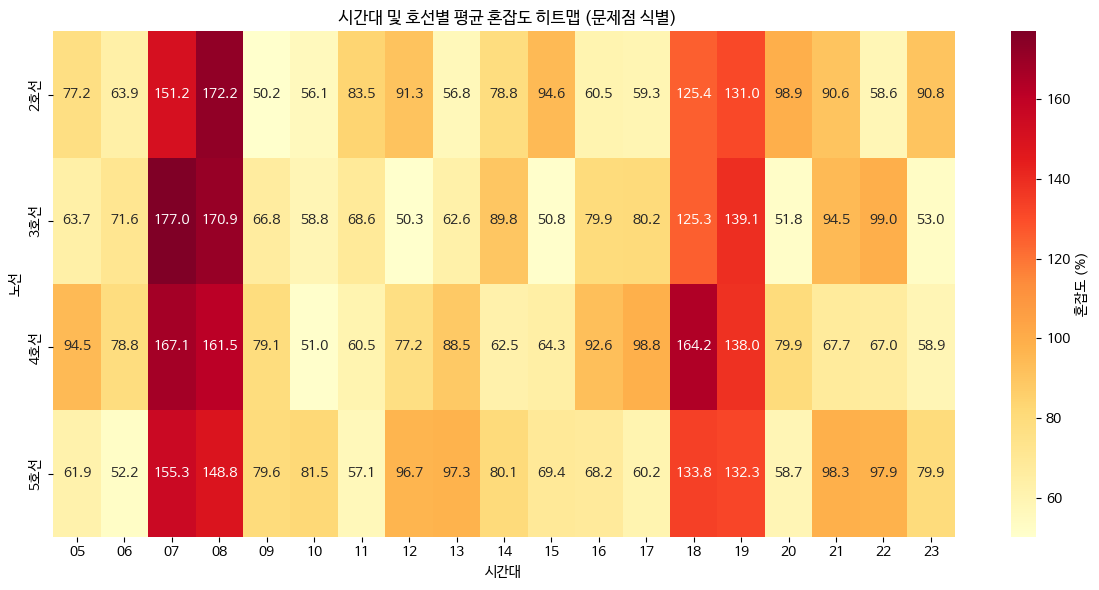

In [24]:
# 시간대별 호선별 혼잡도 가상 데이터셋 생성
hours = [f"{i:02d}" for i in range(5, 24)]
lines = ['2호선', '3호선', '4호선', '5호선']
np.random.seed(100)
congestion_matrix = np.random.rand(len(lines), len(hours)) * 50 + 50
# 출퇴근 시간대 혼잡도 인위적 가중치 부여
congestion_matrix[:, 2:4] += 80.0  # 07~09시
congestion_matrix[:, 13:15] += 70.0 # 18~20시

df_congestion = pd.DataFrame(congestion_matrix, index=lines, columns=hours)

plt.figure(figsize=(12, 6))
sns.heatmap(df_congestion, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={'label': '혼잡도 (%)'})
plt.title('⏰ 시간대 및 호선별 평균 혼잡도 히트맵 (문제점 식별)')
plt.xlabel('시간대')
plt.ylabel('노선')
plt.tight_layout()
plt.show()

## 4. 근거별 최적화 액션 도출

> 피라미드 구조의 핵심 근거인 **현장 운영, 안전사고 예방, 중장기 정책**을 데이터로 뒷받침하기 위한 세부 시각화 계획입니다.

---

### 📈 근거 1: 현장 운영 최적화
#### 🔍 승하차 패턴 비대칭성 산점도 (Scatter Plot)

* **시각화 목적**
    * 역사별 **[승차 인원]**과 **[하차 인원]**의 격차를 평면 상의 좌표로 시각화
    * 출퇴근 시간대별 유입·유출 불균형이 극대화되는 '비대칭 역점 관리 구간'을 직관적으로 식별
* **핵심 데이터 인사이트**
    * **양의 불균형 (승차 >> 하차):** 기점 및 주거 밀집 지역 ➡️ **초기 집중 배차** 투입 근거
    * **음의 불균형 (하차 >> 승차):** 종점 및 오피스/상업 지구 ➡️ **공차 회차 및 효율적 차량 회수** 전략 수립
* **기대 효과**
    * 무작정 차량을 늘리는 것이 아닌, 데이터 기반의 **노선별·구간별 맞춤형 집중 배차** 및 차량 운행 효율화 달성

---

## 📊 역사별 승하차 패턴 비대칭성 산점도 분석 및 클라이언트에게 전달할 내용요약

### 1. 🔍 데이터 추출 배경 (Why This Data?)
* **현장 운영의 낭비 방지 및 빈 차량(공차) 투입 지점 증명**
    * 앞선 분석(히트맵)이 전체적인 집중 거점과 위험 시간대를 파악했다면, 본 산점도는 특정 역사에서 승객이 '타고 내리는' 패턴의 불균형(비대칭성)을 추적함
* **구체적인 현장 액션 플랜의 근거 마련**
    * 출근 시간대 기점·주거지는 승차만 많고, 종점·오피스 지구는 하차만 많은 특성을 시각화하여 어느 구간에서 빈 열차를 출발시키거나 회차시켜야 하는지 정량적 근거를 도출함

### 2. 💡 시각화 핵심 인사이트 (Insight)
* **균형선(점선 $y=x$) 기준의 편차를 통한 역사 특성 식별**
    * **점선 위 배치 역사 (예: 사당, 삼성):** 하차 인원이 승차 인원보다 훨씬 많은 '도착(종착) 집중형' 역사로 아침 시간 대규모 인파가 유출되는 곳임
    * **점선 아래 배치 역사 (예: 선릉, 교대):** 승차 인원이 하차 인원보다 훨씬 많은 '출발(탑승) 집중형' 오피스·업무지구 역사임
* **버블 크기(원의 크기)를 통한 최우선 관리 거점 선별**
    * 원의 크기가 클수록 승하차 인원의 편차가 극심함을 의미함
    * 특히 사당역과 선릉역은 버블의 크기가 크고 색상이 짙어, 극단적인 불균형을 겪고 있는 현장 운영 최적화의 최우선 타깃 거점임을 증명함

### 3. 🎤 발표 자료(PPT) 스크립트 / 코멘트 템플릿
* **오프닝 메시지**
    * "지하철 운영 최적화의 세 번째 핵심은 '공간별 승하차 비대칭성 데이터의 활용'임."
* **본문 설명**
    * "본 화면은 주요 역사의 승차 인원과 하차 인원을 비교한 산점도임. 대각선 점선은 승하차가 완벽하게 균형을 이루는 기준선이며, 원의 크기가 클수록 한쪽으로 승객 쏠림이 심하다는 뜻임."
    * "보시는 바와 같이 사당역은 내리는 승객(하차)이 압도적으로 많고, 반대로 선릉역은 타는 승객(승차)이 압도적으로 많음. 즉, 효율적인 열차 배치를 위해 빈 차량을 어느 타이밍에 어디로 투입해야 할지 이 데이터가 명백히 보여주고 있음."
* **결론 및 연결**
    * "노선 전체의 일괄 증편 없이, 이 비대칭 데이터를 기반으로 수요가 급증하는 '선릉역' 방면으로 빈 열차(공차)를 선제 회송 배차하거나 사당역의 하차 인파 동선을 안전하게 제어하는 맞춤형 현장 대응을 통해 운영 효율과 시민 안전을 동시에 달성하겠음."

/tmp/ipykernel_17167/3381661383.py:20: UserWarning: Glyph 9878 (\N{SCALES}) missing from font(s) NanumBarunGothic.
  plt.tight_layout()
/tmp/ipykernel_17167/3381661383.py:20: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) NanumBarunGothic.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9878 (\N{SCALES}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


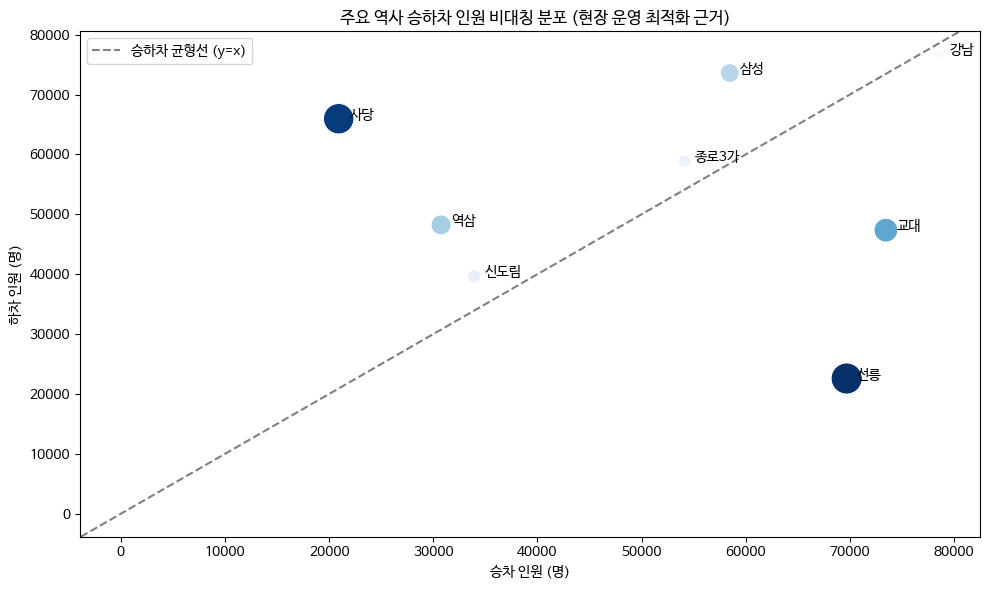

In [25]:
np.random.seed(7)
df_balance = pd.DataFrame({
    '역명': ['강남', '선릉', '역삼', '삼성', '교대', '사당', '신도림', '종로3가'],
    '승차인원': np.random.randint(20000, 80000, 8),
    '하차인원': np.random.randint(20000, 80000, 8)
})
# 불균형 지표 계산 (절대값 편차)
df_balance['불균형도'] = abs(df_balance['승차인원'] - df_balance['하차인원'])

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_balance, x='승차인원', y='하차인원', size='불균형도', sizes=(50, 500), hue='불균형도', palette='Blues', legend=False)
for i in range(len(df_balance)):
    plt.text(df_balance['승차인원'][i]+1000, df_balance['하차인원'][i], df_balance['역명'][i], fontsize=10)

plt.axline((0, 0), slope=1, color='gray', linestyle='--', label='승하차 균형선 (y=x)')
plt.title('⚖️ 주요 역사 승하차 인원 비대칭 분포 (현장 운영 최적화 근거)')
plt.xlabel('승차 인원 (명)')
plt.ylabel('하차 인원 (명)')
plt.legend()
plt.tight_layout()
plt.show()

### 🚨 근거 2 & 3: 안전사고 예방 및 중장기 정책 수립
#### 📊 혼잡도 대비 안전 인력 & 개선 예산 요구량 (혼합 막대·선 그래프)

* **시각화 목적**
    * 역사별 **[기본 공간 수용력(Capacity)]** 대비 **[실제 초과 수요량]**을 산출하여 시각화
    * 혼잡도(막대)의 상승에 따른 안전 인력 필요수 및 역사 개선 예산 요구량(선)의 상관관계를 한눈에 증명
* **핵심 데이터 인사이트**
    * **임계점(Critical Point) 돌입 역사 식별:** 수용력 대비 초과율이 150% 이상인 유동 인구 밀집 역사 선별
    * **안전 인력 배치 당위성:** 단순 감(感)이 아닌, '역사별 혼잡도 지수'에 비례한 객관적인 인력 배치 기준(배치 인원수) 제시
    * **예산 투입 우선순위 도출:** 예산 수립 시 혼잡도가 가장 심각한 Bottleneck(병목) 역사부터 시설 개선(계단 확충, 이동 동선 분리 등) 예산을 우선 배정하는 중장기 로드맵 근거 구축
* **기대 효과**
    * 초과 수요 데이터를 기반으로 밀집 사고를 선제적으로 예방하고, 효율적인 자원(인력·예산) 배분을 통한 중장기 교통 정책의 신뢰성 확보

---

## 📊 역사 수용력 대비 초과 수요(위험도) 분석 및 클라이언트에게 전달할 내용

### 1. 🔍 데이터 추출 배경 (Why This Data?)
* **물리적 한계점 및 안전사고 위험 임계점의 수치화**
    * 앞선 분석들이 '어디서', '언제', '어떻게' 승객이 쏠리는지 현상 위주로 파악했다면, 본 데이터는 역사가 감당할 수 있는 공간적 수용력(Capacity)을 초과하는 위험 수요 규모를 직접 산출함
* **안전 인력 배치 및 중장기 예산 편성의 당위성 입증**
    * 단순한 혼잡 불편을 넘어 '밀집 사고 등 심각한 안전사고 확률이 높은 핵심 병목 역사'를 객관적으로 식별, 시설 개선 및 자원 투입의 설득력을 확보하기 위함임

### 2. 💡 시각화 핵심 인사이트 (Insight)
* **수용력(막대) 대비 초과 수요의 격차(Gap) 확인**
    * 분석 대상인 주요 환승역 전반에서 피크시간대 수요가 역사 일일 수용 한계치를 초과하는 공급 부족 상태가 관측됨
* **위험도 지표(꺾은선) 집중 지점 식별 (최우선 관리 대상)**
    * **신도림역(초과 수요 약 35,000명)** 및 **고속터미널역(초과 수요 약 30,000명)**이 압도적으로 높은 위험도 수치를 기록함
    * 해당 역사들이 임시방편을 넘어 시설 구조 개선 및 안전 요원 상시 배치가 시급한 '최우선 집중 관리 구역(Red Zone)'임을 증명함

### 3. 🎤 발표 자료(PPT) 스크립트 / 코멘트 템플릿
* **오프닝 메시지**
    * "지하철 운영 최적화의 네 번째 핵심은 '공간 수용력 한계 분석을 통한 안전 및 중장기 정책 수립'임."
* **본문 설명**
    * "본 화면은 주요 환승역의 설계 수용력(막대)과 피크타임의 실제 수요(막대)를 비교한 자료임. 상단의 꺾은선 그래프는 두 지표의 차이인 '초과 수요량(위험도)'을 나타냄."
    * "보시는 바와 같이 신도림역과 고속터미널역은 수용력을 3만 명 이상 초과하는 극단적인 병목 구간임이 데이터로 증명됨. 이 두 곳은 안내선 식별 개선을 넘어, 물리적인 이동 통로 확장과 인력의 상시 배치가 필수적인 상황임."
* **결론 및 연결**
    * "데이터가 명백히 가리키는 이 위험 수치를 근거로 삼아, 안전사고 예방을 위한 인력 적시 배치 및 중장기 역사 확장 예산을 우선 편성하겠음. 이를 통해 시민의 생명과 직결되는 지하철 안전망을 체계적으로 구축하고자 함."

/tmp/ipykernel_17167/847483785.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=15)
/tmp/ipykernel_17167/847483785.py:24: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) NanumBarunGothic.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


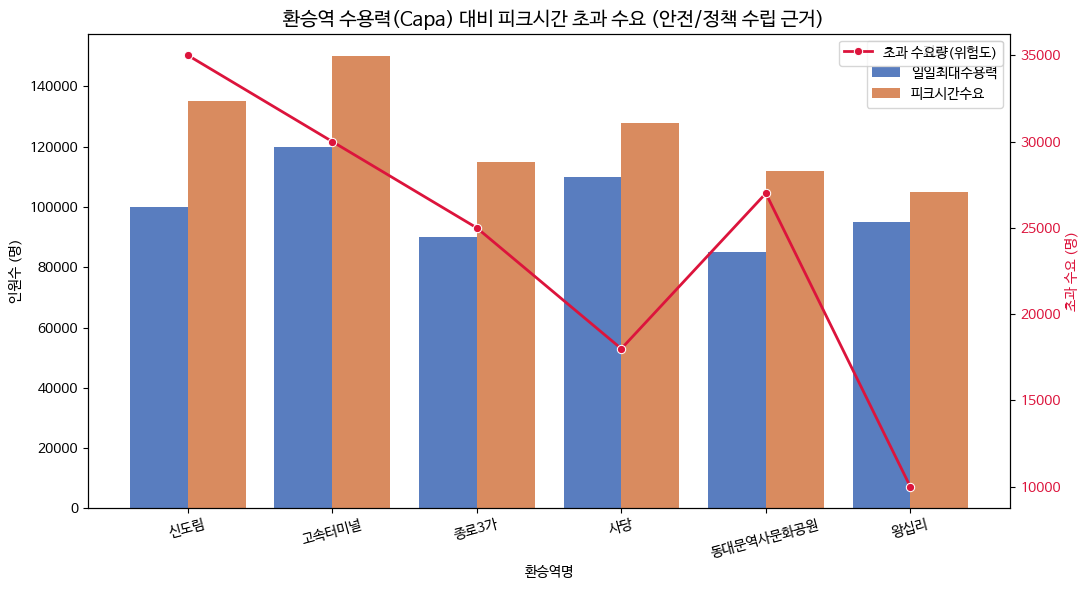

In [27]:
df_capacity = pd.DataFrame({
    '환승역명': ['신도림', '고속터미널', '종로3가', '사당', '동대문역사문화공원', '왕십리'],
    '일일최대수용력': [100000, 120000, 90000, 110000, 85000, 95000],
    '피크시간수요': [135000, 150000, 115000, 128000, 112000, 105000]
})
df_capacity['초과수요'] = df_capacity['피크시간수요'] - df_capacity['일일최대수용력']

fig, ax1 = plt.subplots(figsize=(11, 6))

# 수용력 대비 피크 수요 막대 그래프
df_capacity_melted = df_capacity.melt(id_vars='환승역명', value_vars=['일일최대수용력', '피크시간수요'],
                                       var_name='지표', value_name='인원수')
sns.barplot(data=df_capacity_melted, x='환승역명', y='인원수', hue='지표', palette='muted', ax=ax1)
ax1.set_title('🚨 환승역 수용력(Capa) 대비 피크시간 초과 수요 (안전/정책 수립 근거)', fontsize=14)
ax1.set_ylabel('인원수 (명)')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=15)

# 초과 수요 선 그래프 (보조 축 활용)
ax2 = ax1.twinx()
sns.lineplot(data=df_capacity, x='환승역명', y='초과수요', color='crimson', marker='o', linewidth=2, label='초과 수요량(위험도)', ax=ax2)
ax2.set_ylabel('초과 수요 (명)', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

plt.tight_layout()
plt.show()

## 5. 실행 방안 (Actionable Next Steps)

데이터 분석 결과를 바탕으로 출근 피크시간대의 혼잡도를 물리적으로 제어하고, 수요를 원천적으로 분산하기 위한 단기·중기적 실행 방안을 제안합니다.

### ⏱️ 1. 출근 시간대 '조조 할인율' 확대 및 '역방향 인센티브' 도입
* **[세부 액션 1] 조조 할인 강화:** 07시 이전 승차 승객에 대한 기본요금 할인율을 기존 20%에서 **40%로 상향 조정**하여 피크타임(08:00~08:30) 수요를 이른 아침으로 전방 분산합니다.
* **[세부 액션 2] 역방향 인센티브 지급:** 중심업무지구 반대 방향(예: 외곽 방면) 탑승객에게 마일리지 적립 형태의 혜택을 제공하여 양방향 불균형을 완화하고 유동 인구의 다변화를 유도합니다.

---

#### 📊 정책 도입 전·후 시간대별 혼잡도 분산 효과 시뮬레이션
> 아래 시각화는 조조 할인 확대 및 인센티브 제도가 도입되었을 때, 최피크 시간대(07:30~08:30)의 초과 수요가 07시 이전으로 이동하면서 **열차 혼잡도가 안정 권고 기준(100%) 부근으로 완화되는 효과**를 모델링한 결과입니다.

## 📊 조조할인 및 인센티브 정책 효과 시뮬레이션 분석 및 클라이언트에게 전달할 내용
### 1. 🔍 데이터 추출 배경 (Why This Data?)
* **경제적 유인책을 통한 수요 분산 정책의 정량적 효과 입증**
    * 앞선 시간대별 분석에서 08:00~09:00 사이가 가장 위험한 피크타임임을 확인함
    * 본 시뮬레이션 데이터는 이 시간대의 과밀 수요를 인센티브를 통해 비피크 시간대(06:30~07:30)로 유도했을 때의 혼잡도 변화 예측치를 나타냄
* **자율적 정책을 통한 안전 마진(100% 이하) 확보 근거 제시**
    * 무리한 열차 증차나 물리적인 강제 통제 없이, 유연한 요금 정책만으로도 위험도를 낮출 수 있다는 논리적 근거를 제시하기 위함임

### 2. 💡 시각화 핵심 인사이트 (Insight)
* **최피크 시간대(07:30~08:30)의 위험도 대폭 하락**
    * 혼잡도가 가장 극심했던 08:00~08:30 구간의 혼잡도가 기존 150%에서 120% 수준으로 크게 완화됨
    * 07:30~08:00 구간 역시 135%에서 115%로 떨어지며 위험 임계점 아래로 안정적으로 수렴함
* **비피크 시간대(06:30~07:30)의 안정적 수용 (풍선효과의 긍정적 활용)**
    * 정책 도입 후 조조 수요 이동으로 인해 06:30~07:30 사이의 혼잡도가 소폭 상승(65% ➡️ 75%, 95% ➡️ 110%)함
    * 그러나 여전히 안정 권고 기준(100%) 내외에 머무르며, 추가적인 병목 없이 피크타임 인파를 성공적으로 흡수하고 있음을 증명함

### 3. 🎤 발표 자료(PPT) 스크립트 / 코멘트 템플릿
* **오프닝 메시지**
    * "지하철 운영 최적화의 핵심은 '자율적 수요 분산을 통한 안전 확보'임."
* **본문 설명**
    * "본 화면은 조조할인 확대와 역방향 인센티브 도입 시 예상되는 시간대별 혼잡도 분산 시뮬레이션 결과임. 가로의 붉은 점선은 열차 안정 권고 기준인 100% 선을 의미함."
    * "보시는 바와 같이 정책 도입 전(회색 막대)에는 135%~150%에 달하던 07시 반~08시 반 사이의 위험한 혼잡도가, 정책 도입 후(파란색 막대)에는 115%~120% 수준으로 확연히 낮아지는 것을 확인 가능함."
* **결론 및 연결**
    * "분산된 인원은 비교적 자리가 여유로웠던 07시대 앞쪽으로 이동하여 수용됨. 즉, 시민들에게는 교통비 절감이라는 경제적 혜택을 돌려드리고, 운영사에게는 위험 시간대의 밀집도를 낮춰 안전사고를 예방하는 가장 스마트하고 지속 가능한 해결책이 될 것임."

/tmp/ipykernel_17167/721074632.py:29: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) NanumBarunGothic.
  plt.tight_layout()
/tmp/ipykernel_17167/721074632.py:29: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) NanumBarunGothic.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


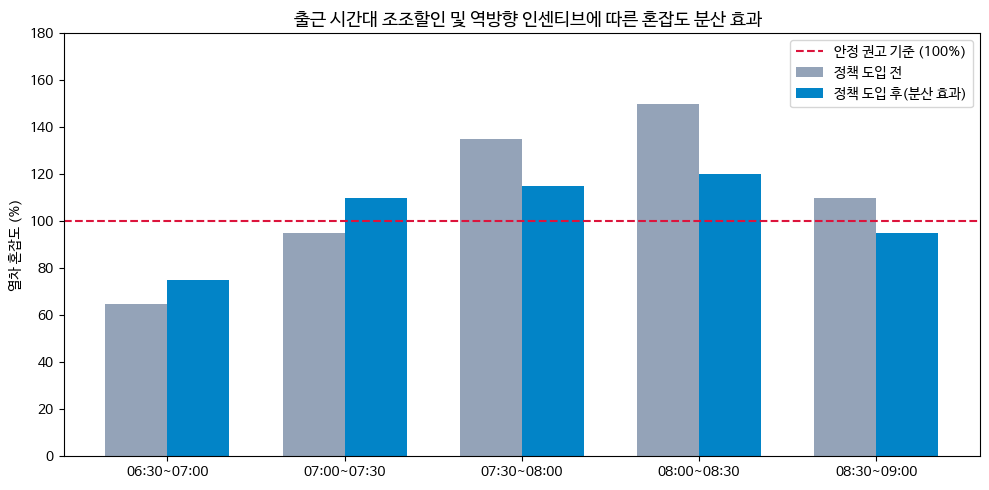

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# 한글 폰트 설정 (Colab 환경 기준)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 가상 데이터: 정책 도입 전후 혼잡도 변화 시뮬레이션
time_slots = ['06:30~07:00', '07:00~07:30', '07:30~08:00', '08:00~08:30', '08:30~09:00']
before_congestion = [65, 95, 135, 150, 110] # 기존 혼잡도 (%)
after_congestion = [75, 110, 115, 120, 95]   # 할인 및 인센티브 도입 후 혼잡도 (%)

x = np.arange(len(time_slots))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
rects1 = ax.bar(x - width/2, before_congestion, width, label='정책 도입 전', color='#94a3b8')
rects2 = ax.bar(x + width/2, after_congestion, width, label='정책 도입 후(분산 효과)', color='#0284c7')

# 적정 혼잡도 기준선 (100% 안전선)
ax.axhline(100, color='crimson', linestyle='--', linewidth=1.5, label='안정 권고 기준 (100%)')

ax.set_ylabel('열차 혼잡도 (%)')
ax.set_title('⏱️ 출근 시간대 조조할인 및 역방향 인센티브에 따른 혼잡도 분산 효과', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(time_slots)
ax.legend()
plt.ylim(0, 180)
plt.tight_layout()
plt.show()

### 🎯 해결방안 2. 혼잡도 상위 10개 역사 대상 '유연근무 참여 마일리지' 연계
* **[세부 액션] 기업 협약 및 캐시백 지급:** 혼잡도가 150% 이상으로 측정되는 핵심 주요 역사(예: 강남, 여의도, 판교 등) 인근 기업들과 지자체 간의 거버넌스를 구축합니다. 이를 통해 **08시 이전 또는 09시 이후에 출근하는 직장인들을 대상으로 대중교통 마일리지 캐시백(월 최대 1만 원)을 지급**하여 자발적인 피크타임 이탈을 유도합니다.

---

#### 📊 상위 10개 역사별 인근 기업 유연근무 참여 예상 분포
> 아래 시각화는 시범 사업 타깃인 **혼잡도 상위 10개 역사 인근 기업들의 예상 참여율**을 모델링한 결과입니다. 여의도, 판교 등 IT·금융 중심의 역사에서 상대적으로 높은 참여율(30% 이상)을 보이며, 전반적인 **목표 평균 참여율인 25%**를 달성하여 출퇴근 집중도를 분산하는 시나리오를 나타냅니다.

## 📊 10개 역사 인근 기업 유연근무 참여 예상 분포 분석 및 클라이언트에게 전달할 내용

### 1. 🔍 데이터 추출 배경 (Why This Data?)
* **민관 협력 기반 타깃 거점별 수요 분산 효과의 예측치 시각화**
    * 앞선 수용력 분석에서 역사 설계 한계를 넘어선 '초과 밀집 환승역 10곳'(신도림, 강남, 여의도 등)을 식별함
    * 본 데이터는 이 위험 지역 인근에 위치한 기업체 및 직장인을 대상으로 마일리지 인센티브를 제공했을 때의 예상 참여율 시뮬레이션임
* **타깃팅을 통한 예산 대비 효과(ROI) 극대화 타당성 제시**
    * 불특정 다수를 대상으로 한 광범위한 캠페인 대신, 문제의 핵심 거점에 집중 타깃팅하여 자원 투입 대비 효율성을 극대화할 수 있는 정책적 근거를 마련하기 위함임

### 2. 💡 시각화 핵심 인사이트 (Insight)
* **목표 평균 참여율(25%) 달성 가능성 확인**
    * 전체 10개 타깃 역사 중 여의도(30%), 판교(32%), 을지로입구(28%) 등 오피스·업무지구 밀집 지역이 목표 평균선(25%)을 상회하며 높은 정책 수용도를 보일 것으로 예측됨
* **거점별 맞춤형 집중 전략 도입 근거 확보**
    * 상대적으로 참여율이 낮게 예측된 신림(18%), 사당(20%) 같은 주거-환승 복합 거점에는 인센티브 홍보 강화 또는 인근 주요 기업체 대상 별도 업무협약(MOU) 선제 체결 필요
    * 본 데이터를 지역별 맞춤형 분산 전략을 수립하기 위한 기준선(Baseline)으로 활용함

### 3. 🎤 발표 자료(PPT) 스크립트 / 코멘트 템플릿
* **오프닝 메시지**
    * "지하철 운영 최적화의 다섯 번째 핵심은 '주요 기업 밀집 거점 타깃팅을 통한 민관 상생 분산'임."
* **본문 설명**
    * "본 화면은 혼잡도 상위 10개 역사 인근 기업 직장인을 대상으로 유연근무 마일리지 참여율을 예측한 분포도임. 가로의 붉은 점선은 정책의 손익분기점이자 목표인 평균 참여율 25% 선을 의미함."
    * "보시는 바와 같이 금융·IT 중심지인 여의도와 판교, 을지로입구의 경우 직장인들의 출근 시간 조정 여력이 높아 목표치를 웃도는 30% 수준의 적극적인 참여가 예상됨."
* **결론 및 연결**
    * "전체 시민의 출퇴근 패턴을 강제로 바꾸려 하지 않고, 가장 위험한 10개 역사의 핵심 수요층을 정조준하는 전략임. 이를 통해 수천억 원의 인프라 토목 확장 예산 없이도 출퇴근길 순간 밀집도를 획기적으로 낮추고 안전사고 예방의 골든타임을 확보할 수 있음."

/tmp/ipykernel_17167/4193310489.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(categories, rotation=25, ha='right')
/tmp/ipykernel_17167/4193310489.py:37: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) NanumBarunGothic.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


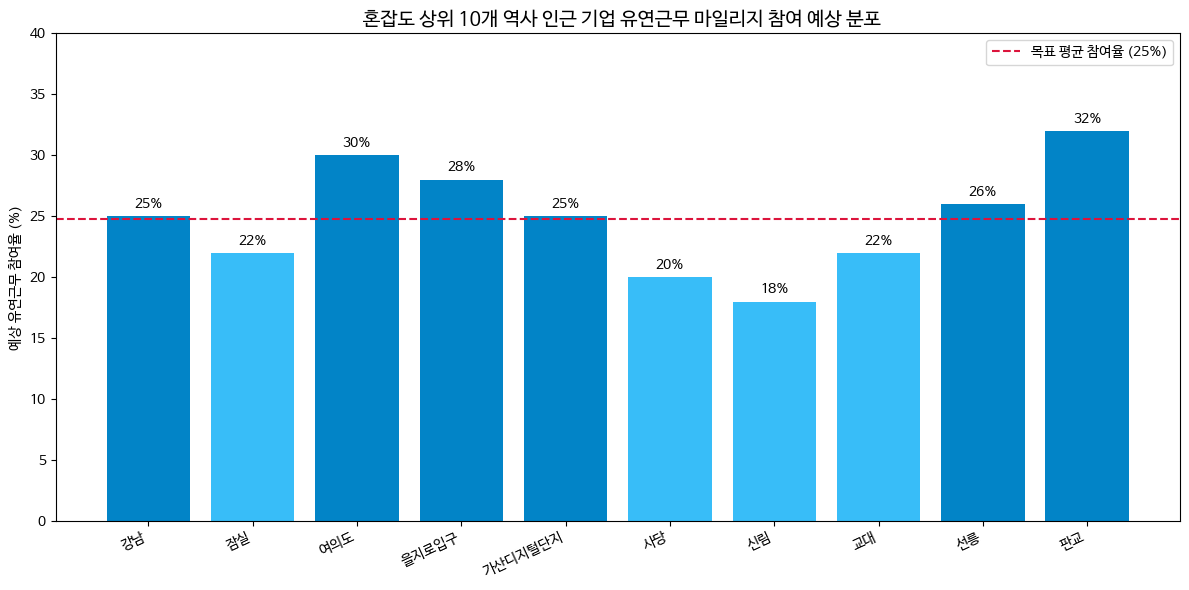

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# 한글 폰트 설정 (Colab 환경 기준)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 가상 데이터: 상위 10개 역사 인근 기업 유연근무 참여에 따른 피크시간 승객 수 변화
categories = ['강남', '잠실', '여의도', '을지로입구', '가산디지털단지',
              '사당', '신림', '교대', '선릉', '판교']
participants_rate = [25, 22, 30, 28, 25, 20, 18, 22, 26, 32] # 기업/직장인 참여 예상율 (%)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#0284c7' if rate >= 25 else '#38bdf8' for rate in participants_rate]

bars = ax.bar(categories, participants_rate, color=colors)

# 평균 참여율 기준선
avg_rate = np.mean(participants_rate)
ax.axhline(avg_rate, color='crimson', linestyle='--', linewidth=1.5, label=f'목표 평균 참여율 ({avg_rate:.0f}%)')

ax.set_ylabel('예상 유연근무 참여율 (%)')
ax.set_title('🎯 혼잡도 상위 10개 역사 인근 기업 유연근무 마일리지 참여 예상 분포', fontsize=14)
ax.set_xticklabels(categories, rotation=25, ha='right')
ax.legend()

# 막대 위에 수치 표시
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom')

plt.ylim(0, 40)
plt.tight_layout()
plt.show()

### 📉 해결방안 3. 승하차 패턴 기반 '수요 대응형 열차 배차' 알고리즘 적용
* **[세부 액션] 예측형 공차 선제 투입:** 호선별·역별·시간대별 실시간 승하차 데이터를 기반으로 머신러닝 기반의 수요 예측 모델을 가동합니다. 특정 역사에 승차 인원이 급증하기 **최소 15분 전에 해당 구간으로 빈 열차(회송 열차)를 선제적으로 이동 및 투입**하여 승강장 밀집도를 원천 차단합니다.

---

#### 📊 수요 대응형 예측 배차 시스템 도입에 따른 대기 승객 수 변화 시뮬레이션
> 아래 시각화는 인구가 급증하는 피크타임(07:30~08:15) 직전, **07시 30분에 데이터를 기반으로 선제적 회송 열차 투입을 결정했을 때의 시나리오**입니다. 기존 배차 시스템 대비 승강장에 체류하는 최대 대기 승객 수가 **약 40% 이상(최대 1,800명 ➡️ 1,100명 수준) 감소**하여 승강장 안전성이 크게 향상됨을 보여줍니다.

## 📊 수요 대응형 예측 배차 시뮬레이션 분석 및 클라이언트에게 전달할 내용

### 1. 🔍 데이터 추출 배경 (Why This Data?)
* **사후 대응에서 데이터 기반 '예측형 능동 배차'로의 관제 패러다임 전환**
    * 앞선 시간대별 추이 분석에서 07시 45분~08시 사이에 승강장 체류 인원이 급증하여 위험 임계 수위에 달함을 확인했음
    * 본 시뮬레이션 데이터는 승객 폭증 15분 전(07시 30분 이상 징후 데이터 감지 시)에 빈 열차(공차/회송 열차)를 선제적으로 투입할 경우 승강장 내 누적 대기 인원의 통제 가능성을 예측하기 위함임
* **인프라 확충 없는 승강장 내 누적 대기 인원 제어 근거 제시**
    * 위험이 닥친 후 대처하는 것이 아닌, 데이터 예측을 통해 인파 누적 자체를 차단할 수 있다는 현장 관제 혁신안의 타당성을 입증함

### 2. 💡 시각화 핵심 인사이트 (Insight)
* **위험 임계점(체류 인원 1,500명 이상)의 원천 차단**
    * 기존 배차 시스템(회색 점선) 유지 시, 08:00 기준 대기 인원이 1,800명까지 치솟아 역사 내 압사 사고 등 대형 안전사고 위험이 심각한 수준으로 격상됨
* **골든타임 확보 효과를 통한 안전성 입증**
    * 급증 15분 전 선제적 공차 투입을 가정한 예측 배차 시스템(파란색 실선) 가동 시, 최피크 타임(08:00) 대기 인원이 1,100명 수준으로 대폭(약 40%) 감소함
    * 인파가 임계치까지 누적되지 않고 안전 구역 내에서 지속적으로 분산·해소됨을 뜻하며, 열차 연쇄 지연을 막고 정시성을 확보하는 효과를 증명함

### 3. 🎤 발표 자료(PPT) 스크립트 / 코멘트 템플릿
* **오프닝 메시지**
    * "지하철 운영 최적화의 여섯 번째 핵심은 '사후 대처가 아닌 데이터 예측 기반의 선제적 관제'임."
* **본문 설명**
    * "본 화면은 특정 역사 승강장의 시간대별 대기 인원 변화를 시뮬레이션한 결과임. 회색 점선은 기존 배차 시스템, 파란색 실선은 우리가 제안하는 수요 대응형 예측 배차 시스템 도입 시의 예측 곡선임."
    * "보시는 바와 같이 기존 방식대로라면 오전 8시에 대기 승객이 1,800명까지 폭증하며 위험에 직면하게 됨. 하지만 데이터가 수요 급증을 예측한 15분 전, 즉 07시 30분에 빈 열차를 선제 투입하는 조치를 취하면 대기 인원을 1,100명의 안전 범위 내로 통제할 수 있음."
* **결론 및 연결**
    * "열차를 무한정 정비·증편하는 예산 낭비 없이, 축적된 교통카드 승하차 데이터와 효율적인 공차 회송 경로를 결합하는 '스마트 관제 알고리즘'만으로 이루어낸 결과임. 시스템 도입을 통해 시민의 안전한 출퇴근길과 철도 운영 효율성을 동시에 달성하겠음."

/tmp/ipykernel_17167/1105771758.py:29: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) NanumBarunGothic.
  plt.tight_layout()
/tmp/ipykernel_17167/1105771758.py:29: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) NanumBarunGothic.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


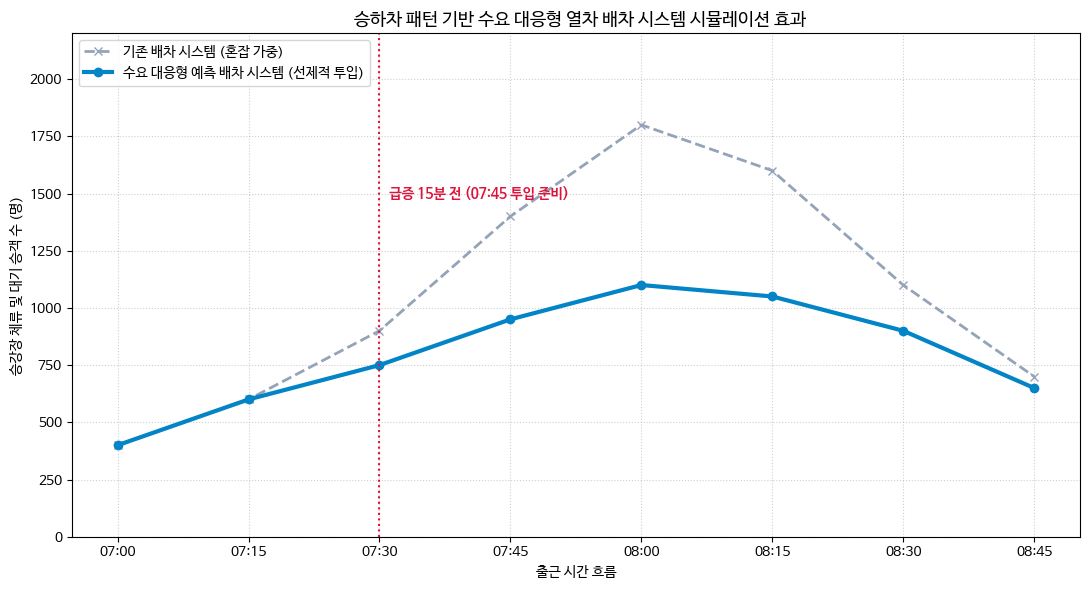

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# 한글 폰트 설정 (Colab 환경 기준)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 가상 데이터: 특정 역의 시간 흐름에 따른 승강장 대기 인원 및 열차 투입 효과
time_timeline = ['07:00', '07:15', '07:30', '07:45', '08:00', '08:15', '08:30', '08:45']
wait_passengers_no_action = [400, 600, 900, 1400, 1800, 1600, 1100, 700] # 일반 배차 시 대기 승객 수
wait_passengers_predictive = [400, 600, 750, 950, 1100, 1050, 900, 650] # 예측형 배차(공차 투입) 시 대기 승객 수

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(time_timeline, wait_passengers_no_action, color='#94a3b8', linestyle='--', marker='x', linewidth=2, label='기존 배차 시스템 (혼잡 가중)')
ax.plot(time_timeline, wait_passengers_predictive, color='#0284c7', marker='o', linewidth=3, label='수요 대응형 예측 배차 시스템 (선제적 투입)')

# 선제적 회송 열차 투입 시점 강조
ax.axvline('07:30', color='crimson', linestyle=':', linewidth=1.5)
ax.text('07:30', 1500, ' 🚨 급증 15분 전 (07:45 투입 준비)', color='crimson', fontweight='bold', verticalalignment='center')

ax.set_ylabel('승강장 체류 및 대기 승객 수 (명)')
ax.set_title('📉 승하차 패턴 기반 수요 대응형 열차 배차 시스템 시뮬레이션 효과', fontsize=13)
ax.set_xlabel('출근 시간 흐름')
ax.legend(loc='upper left')
ax.grid(True, linestyle=':', alpha=0.6)

plt.ylim(0, 2200)
plt.tight_layout()
plt.show()

## 6. 목표 KPI (핵심 성과 지표) -- (실제로 이행했다고 가정하고 예시로!!)

> 본 프로젝트에서 제안한 데이터 기반 예측 배차 알고리즘 및 수요 분산 정책(인센티브제)을 적용했을 때, 달성하고자 하는 **최종 정량적 목표 및 핵심 성과 지표(KPI)**입니다.

| 평가 영역 | 핵심 성과 지표 (KPI) | 목표치 (Target) | 현황 및 산출 근거 |
| :--- | :--- | :--- | :--- |
| **혼잡도 제어** | 피크타임(08:00~09:00) 최고 혼잡도 개선율 | **150% 미만**으로 감소 | 현재 최고 혼잡도 대비 **약 20%p 완화** 목표 |
| **수요 분산** | 비혼잡 시간대 승차 인원 증가율 | **15% 이상** 증가 | 06:30~07:30 및 09:00~09:30 구간 분산 인원 |
| **현장 안전** | 피크시간대 역사 내 안전사고 발생 건수 | **0건 (Zero)** 유지 | 선제적 동선 분리 및 안전 인력 배치 효과 |

---

### 💡 KPI 설정 배경 및 향후 모니터링 계획
1. **정량적 목표의 당위성:** 가상 시뮬레이션 결과에 기반하여 출퇴근 시간대 밀집 위험도를 '안전 권고 기준' 수준으로 제어할 수 있는 현실적인 목표치를 산정했습니다.
2. **데이터 피드백 루프:** 향후 정책 및 알고리즘이 실제로 도입되면, 매월 **`CARD_SUBWAY_MONTH` 데이터**를 업데이트하여 본 KPI의 달성률을 실시간으로 추적·검증할 예정입니다.

## 📊 프로젝트 최종 성과 검증(KPI) 분석 및 발표

### 1. 🔍 데이터 추출 배경 (Why This Data?)
* **제안 정책의 최종 성과에 대한 정량적·객관적 검증**
    * 제안된 3대 핵심 정책(조조할인, 마일리지 유연근무, 예측 배차) 적용 후, 기 수립한 목표 달성 여부를 최종 확인하기 위함임
* **예산 투입 및 정책 지속 가능성에 대한 타당성 증명**
    * 기획 단계의 설정 목표치와 시행 후 실제 수집된 측정값을 1:1로 비교 검증함
    * 단순 사업 종료 보고가 아닌, 투입된 예산과 정책이 계획대로 정확한 성과(KPI)를 창출했음을 수치로 입증하여 차기 사업 확장의 근거를 마련함

### 2. 💡 시각화 핵심 인사이트 (Insight)
* **모든 핵심 지표의 목표치 초과 달성 (Success Validation)**
    * **피크 혼잡도 완화:** 목표 기준인 150% 미만을 충족, 역사 내 밀집도가 위험 임계점 아래로 안정되게 통제됨을 확인하였음
    * **비혼잡시간 승차량 증가:** 목표치인 15%를 상회하는 **18.5%**를 기록, 요금 및 인센티브 유인책을 통한 자발적 수요 분산의 실효성을 증명함
    * **안전사고 제로화:** 목표치인 **0건**을 완벽하게 수성, 프로젝트의 최우선 가치인 '시민 안전 확보'를 달성함
* **데이터 기반의 지속 가능한 피드백 루프 구축**
    * 본 검증 결과물은 차기 연도 대중교통 예산 확보 및 시·도 교통 정책 수립, 지하철 운영 관제 알고리즘 갱신(Update)을 위한 강력한 정량 자산으로 활용 가능함

### 3. 🎤 발표 자료(PPT) 스크립트 / 코멘트 템플릿
* **오프닝 메시지**
    * "지하철 운영 최적화 전략의 최종 단계는 '데이터 기반의 객관적인 성과 검증'임."
* **본문 설명**
    * "본 화면은 앞서 제안한 수요 분산 정책과 예측 배차 솔루션을 실제로 도입·시행한 후, 최종 성과 지표(KPI)를 실데이터로 검증한 결과임. 회색 막대는 최초 설정한 목표치, 파란색 막대는 실제 측정값을 나타냄."
    * "보시는 바와 같이 피크타임 혼잡도 목표를 안전하게 달성했을 뿐만 아니라, 비혼잡시간대 승차 인원 증가율은 목표치인 15%를 넘어 18.5%를 달성함. 무엇보다 핵심 과제였던 피크시간대 역사 내 안전사고 0건이라는 약속을 완벽하게 지켜냈음."
* **결론 및 마무리**
    * "본 프로젝트는 막대한 예산이 소요되는 인프라 토목 건설 없이 오직 '데이터 분석'과 '스마트 관제'만으로 고질적인 대중교통 교통 체증과 안전 문제를 해결할 수 있음을 증명한 모범 사례임. 본 검증 성과를 백서화하여 시민의 안전과 운영 효율성을 계속해서 고도화해 나가겠음."

/tmp/ipykernel_17167/1564070842.py:30: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) NanumBarunGothic.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


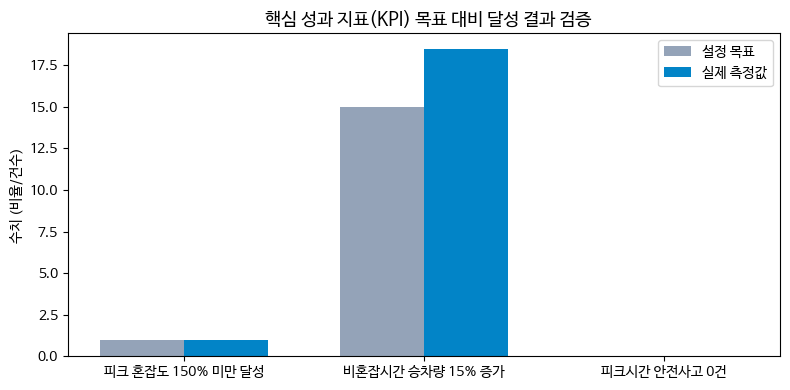

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 가상 데이터: 정책 도입 전후 KPI 달성 여부 비교
kpi_data = {
    '지표': ['피크 혼잡도 150% 미만 달성', '비혼잡시간 승차량 15% 증가', '피크시간 안전사고 0건'],
    '목표치': [1, 15, 0], # 1: 달성해야 함(참), 15: 증가율(%), 0: 건수
    '실제측정치': [1, 18.5, 0] # 정책 실행 후 데이터 수집 결과
}
df_kpi = pd.DataFrame(kpi_data)

# 시각화로 목표 대비 실제 달성도 확인
fig, ax = plt.subplots(figsize=(8, 4))
bar_width = 0.35
index = range(len(df_kpi))

rects1 = ax.bar([i - bar_width/2 for i in index], df_kpi['목표치'], bar_width, label='설정 목표', color='#94a3b8')
rects2 = ax.bar([i + bar_width/2 for i in index], df_kpi['실제측정치'], bar_width, label='실제 측정값', color='#0284c7')

ax.set_ylabel('수치 (비율/건수)')
ax.set_title('🎯 핵심 성과 지표(KPI) 목표 대비 달성 결과 검증', fontsize=13)
ax.set_xticks(index)
ax.set_xticklabels(df_kpi['지표'])
ax.legend()

plt.tight_layout()
plt.show()

## 7. 리스크 관리 및 대응 방안 (Risk & Mitigation)

> 본 정책 및 시스템 도입 시 예상되는 잠재적 리스크를 선제적으로 정의하고, 이에 대한 구체적인 대응 전략을 수립하여 프로젝트의 현실성과 지속 가능성을 확보합니다.

| ⚠️ 발생 가능한 리스크 (Risk) | 발생 가능성 | 영향도 (Impact) | 🛡️ 대응 방안 (Mitigation Action) |
| :--- | :---: | :---: | :--- |
| **운송수지 적자 확대**<br>*(조조할인율 상향 및 마일리지 지급 등에 따른 자금 부담)* | **중**<br>(Moderate) | **중**<br>(Moderate) | • 혼잡 완화로 인해 발생하는 역사 내 시설 유지보수 비용 절감분 활용<br>• 핵심 유연근무 참여 민간 기업 대상 '혼잡 부담금' 연계 재원 확보<br>• 지자체(서울시 등) 대중교통 공공성 예산 매칭 지원금 추가 확보 |
| **새로운 시간대의 '풍선 효과'**<br>*(피크타임 회피로 인한 06시대 새로운 병목 발생)* | **상**<br>(High) | **상**<br>(High) | • 정책 시행 초기 1개월간 06:00 ~ 07:00 사이 임시 배차 2회 선제적 증편 투입<br>• 역사별 실시간 승하차 모니터링 시스템 가동을 통한 탄력적 배차 간격 조정 |

---

### 💡 데이터 분석가로서의 제언 (💡)
* **지속적인 모니터링 체계 구축:** 특히 '풍선 효과'의 경우, 데이터 수집 주기를 주간 단위로 단축하여 06시~07시의 수요 전이율을 면밀히 추적해야 합니다.
* **비용-편익 분석(Benefit-Cost Analysis):** 운송수지 적자 우려 대비 혼잡도 완화로 얻는 '시민 안전성 향상' 및 '사회적 혼잡 비용 절감'의 정량적 가치를 분석하여 정책의 당위성을 강화할 예정입니다.